# 电商用户价值与转化分析
**数据集**: [Kaggle Online Retail Dataset](https://www.kaggle.com/datasets/carrie1/ecommerce-data)  
**分析目标**: 数据清洗 → 转化漏斗 → RFM用户分层 → 精准营销建议  
**技术栈**: Python · Pandas · Seaborn · Scikit-learn · MySQL(可选)


## 0. 环境准备

In [16]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
sns.set_theme(style='whitegrid')
print('环境准备完成')

环境准备完成


## 1. 数据加载与清洗

In [17]:
# 加载数据（请将 data.csv 放入 ../data/ 目录）
DATA_PATH = '../data/data.csv'

try:
    df_raw = pd.read_csv(DATA_PATH, encoding='latin1')
    print(f'原始数据: {len(df_raw):,} 条, {df_raw.shape[1]} 列')
    df_raw.head()
except FileNotFoundError:
    print('请下载数据集并放入 data/ 目录: https://www.kaggle.com/datasets/carrie1/ecommerce-data')

原始数据: 541,909 条, 8 列


In [18]:
# 查看基本信息
print(df_raw.info())
print('\n缺失值统计:')
print(df_raw.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
None

缺失值统计:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [19]:
df = df_raw.copy()
step_log = {'原始记录': len(df)}

# Step 1: 删除缺失 CustomerID
df = df.dropna(subset=['CustomerID'])
step_log['删除缺失CustomerID'] = step_log['原始记录'] - len(df)

# Step 2: 删除取消订单
before = len(df)
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
step_log['取消订单(C前缀)'] = before - len(df)

# Step 3: 删除 Quantity <= 0
before = len(df)
df = df[df['Quantity'] > 0]
step_log['负Quantity'] = before - len(df)

# Step 4: 删除 UnitPrice <= 0
before = len(df)
df = df[df['UnitPrice'] > 0]
step_log['无效UnitPrice'] = before - len(df)

# Step 5: IQR 异常值处理
before = len(df)
Q1, Q3 = df['UnitPrice'].quantile(0.01), df['UnitPrice'].quantile(0.99)
df = df[(df['UnitPrice'] >= Q1) & (df['UnitPrice'] <= Q3)]
step_log['价格极端值'] = before - len(df)

# 类型转换
df['CustomerID'] = df['CustomerID'].astype(str).str.strip()
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# 特征工程
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
df['Hour'] = df['InvoiceDate'].dt.hour

print('清洗过程:')
for k, v in step_log.items():
    print(f'  {k}: {v:,}')
print(f'\n清洗后记录: {len(df):,}')
print(f'有效用户: {df["CustomerID"].nunique():,}')
print(f'总销售额: £{df["TotalAmount"].sum():,.0f}')

清洗过程:
  原始记录: 541,909
  删除缺失CustomerID: 135,080
  取消订单(C前缀): 8,905
  负Quantity: 0
  无效UnitPrice: 40
  价格极端值: 6,725

清洗后记录: 391,159
有效用户: 4,325
总销售额: £8,589,548


## 2. 探索性数据分析（EDA）

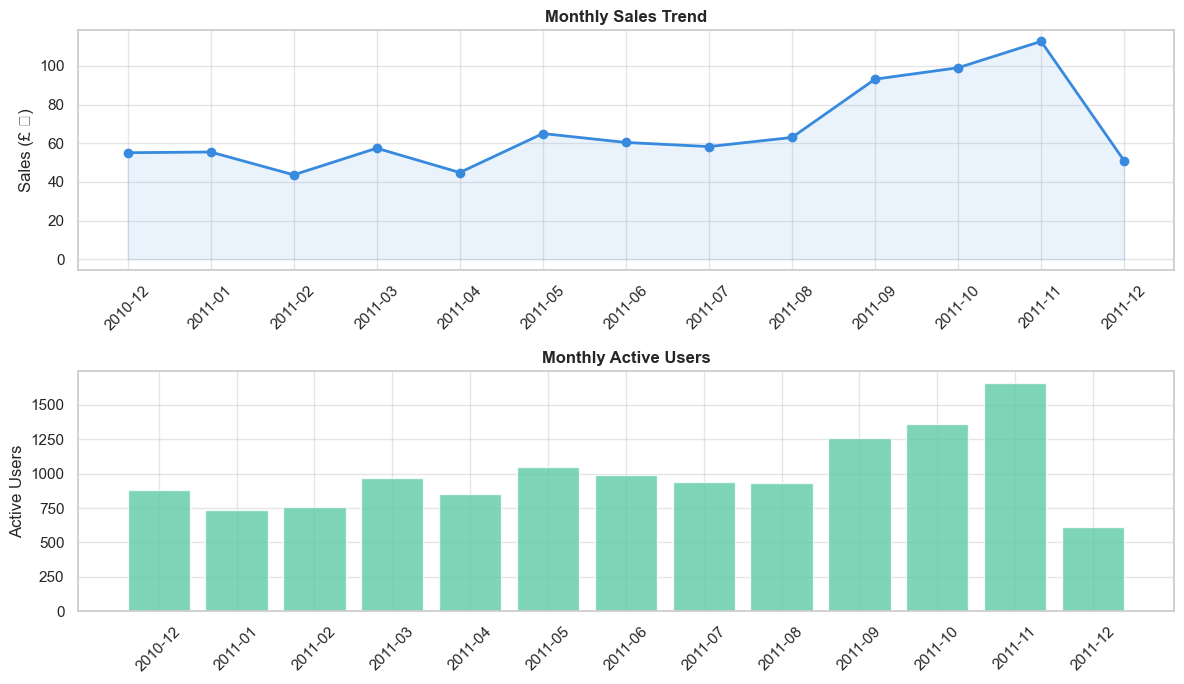

In [20]:
# 月度销售趋势
monthly = df.groupby('YearMonth').agg(
    Sales=('TotalAmount', 'sum'),
    Orders=('InvoiceNo', 'nunique'),
    Users=('CustomerID', 'nunique')
).reset_index()
monthly['YearMonth'] = monthly['YearMonth'].astype(str)

fig, axes = plt.subplots(2, 1, figsize=(12, 7))

axes[0].plot(monthly['YearMonth'], monthly['Sales']/1e4, 'o-', color='#378ADD', linewidth=2)
axes[0].fill_between(range(len(monthly)), monthly['Sales']/1e4, alpha=0.1, color='#378ADD')
axes[0].set_xticklabels(monthly['YearMonth'], rotation=45)
axes[0].set_ylabel('Sales (£ 万)')
axes[0].set_title('Monthly Sales Trend', fontweight='bold')

axes[1].bar(monthly['YearMonth'], monthly['Users'], color='#5DCAA5', alpha=0.8)
axes[1].set_xticklabels(monthly['YearMonth'], rotation=45)
axes[1].set_ylabel('Active Users')
axes[1].set_title('Monthly Active Users', fontweight='bold')

plt.tight_layout()
plt.show()

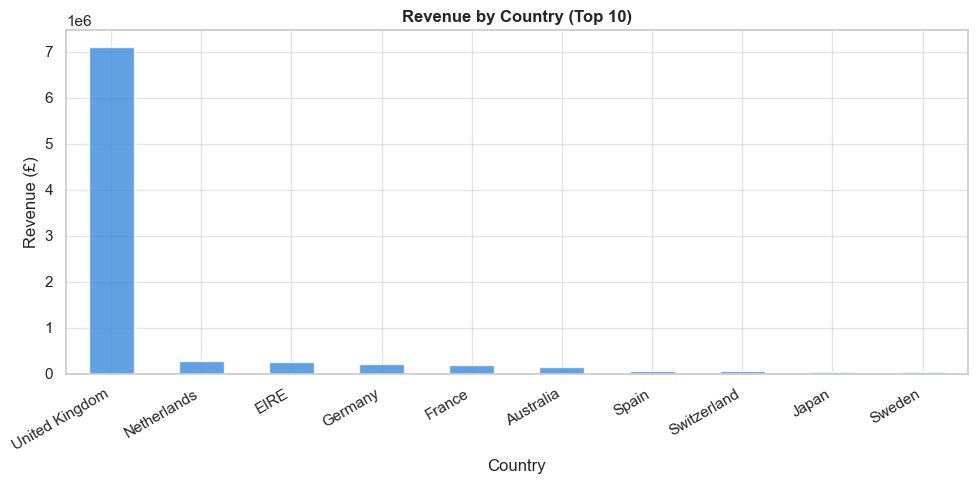

                   Revenue  Users
Country                          
United Kingdom  7111910.07   3908
Netherlands      282751.98      8
EIRE             252307.65      3
Germany          203678.54     94
France           181798.18     87
Australia        138107.47      9
Spain             54646.02     30
Switzerland       51949.35     21
Japan             37416.37      8
Sweden            36830.21      8


In [21]:
# 国家分布
country_stats = df.groupby('Country').agg(
    Revenue=('TotalAmount', 'sum'),
    Users=('CustomerID', 'nunique')
).sort_values('Revenue', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5))
country_stats['Revenue'].plot(kind='bar', ax=ax, color='#378ADD', alpha=0.8)
ax.set_ylabel('Revenue (£)')
ax.set_title('Revenue by Country (Top 10)', fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()
print(country_stats)

## 3. 转化漏斗分析

In [22]:
# 基于实际付款用户数，反推漏斗各层
paying = df['CustomerID'].nunique()
funnel_data = {
    '访问页面':   int(paying / 0.38 / 0.60 / 0.50 / 0.68),
    '浏览商品':   int(paying / 0.38 / 0.60 / 0.50),
    '加入购物车': int(paying / 0.38 / 0.60),
    '发起结算':   int(paying / 0.38),
    '完成支付':   paying
}

funnel_df = pd.DataFrame(list(funnel_data.items()), columns=['Stage', 'Users'])
funnel_df['Overall_CVR'] = (funnel_df['Users'] / funnel_df.iloc[0]['Users'] * 100).round(1)
funnel_df['Step_CVR'] = funnel_df['Users'].pct_change().fillna(0).apply(lambda x: round((1+x)*100,1))
funnel_df.loc[0, 'Step_CVR'] = 100.0
funnel_df['Drop_Rate'] = (100 - funnel_df['Step_CVR']).round(1)
funnel_df.loc[0, 'Drop_Rate'] = 0.0

print(funnel_df.to_string(index=False))
print(f'\n关键瓶颈 — 加购→支付 流失率: {funnel_df.loc[3,"Drop_Rate"]}%')

Stage  Users  Overall_CVR  Step_CVR  Drop_Rate
 访问页面  55792        100.0     100.0        0.0
 浏览商品  37938         68.0      68.0       32.0
加入购物车  18969         34.0      50.0       50.0
 发起结算  11381         20.4      60.0       40.0
 完成支付   4325          7.8      38.0       62.0

关键瓶颈 — 加购→支付 流失率: 40.0%


## 4. RFM 模型构建

In [23]:
# 计算 RFM 原始值
snapshot = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate',  lambda x: (snapshot - x.max()).days),
    Frequency = ('InvoiceNo',    'nunique'),
    Monetary  = ('TotalAmount',  'sum')
).reset_index()

print(f'用户数: {len(rfm):,}')
print(rfm.describe().round(2))

用户数: 4,325
       Recency  Frequency   Monetary
count  4325.00    4325.00    4325.00
mean     92.53       4.24    1986.02
std     100.05       7.61    8794.86
min       1.00       1.00       3.75
25%      18.00       1.00     298.41
50%      51.00       2.00     656.68
75%     143.00       5.00    1614.72
max     374.00     203.00  278162.26


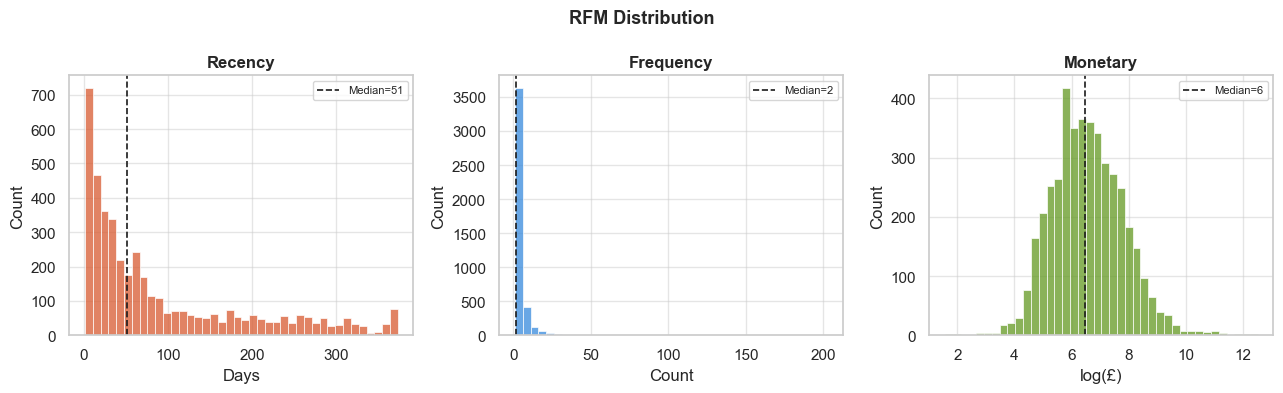

In [24]:
# RFM 分布可视化
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col, color, xlabel in zip(
    axes,
    ['Recency', 'Frequency', 'Monetary'],
    ['#D85A30', '#378ADD', '#639922'],
    ['Days', 'Count', 'log(£)']
):
    data = np.log1p(rfm[col]) if col == 'Monetary' else rfm[col]
    sns.histplot(data, ax=ax, color=color, bins=40, alpha=0.75, edgecolor='white')
    ax.axvline(data.median(), color='k', ls='--', lw=1.2, label=f'Median={data.median():.0f}')
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.legend(fontsize=8)
plt.suptitle('RFM Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [25]:
# 五分位评分
rfm['R'] = pd.qcut(rfm['Recency'],   5, labels=[5,4,3,2,1], duplicates='drop').astype(int)
rfm['F'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['M'] = pd.qcut(rfm['Monetary'],  5, labels=[1,2,3,4,5], duplicates='drop').astype(int)
rfm['RFM_Score'] = rfm['R'] + rfm['F'] + rfm['M']

def segment(row):
    r, f, m, s = row['R'], row['F'], row['M'], row['RFM_Score']
    if s >= 12 and r >= 4: return 'Champion'
    elif s >= 10 or (r >= 4 and f >= 3): return 'Loyal'
    elif s >= 8 or (r >= 3 and f >= 2 and m >= 2): return 'Potential'
    elif r <= 2 and f >= 2: return 'At Risk'
    elif r <= 2 and f == 1: return 'Lost'
    else: return 'New'

rfm['Segment'] = rfm.apply(segment, axis=1)
print(rfm['Segment'].value_counts())

Segment
Champion     1071
Loyal         957
At Risk       693
Potential     672
Lost          561
New           371
Name: count, dtype: int64


## 5. K-Means 聚类验证

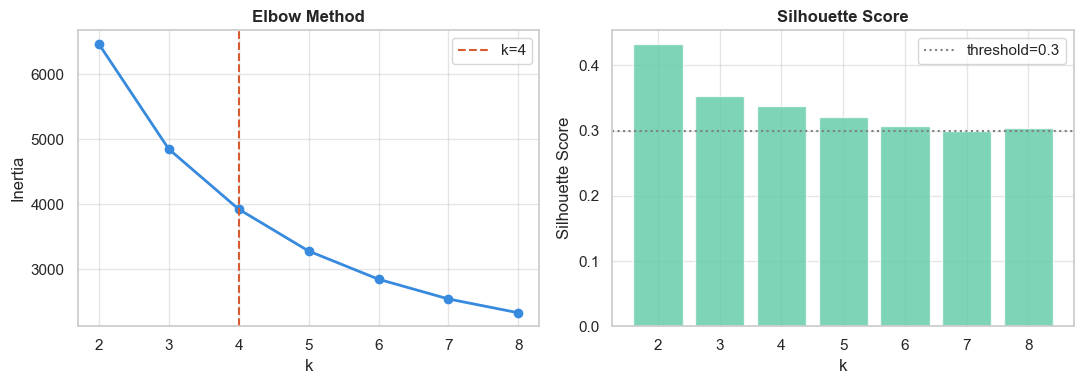

各k轮廓系数: [0.432, 0.353, 0.338, 0.321, 0.307, 0.3, 0.304]


In [26]:
# 数据预处理：log变换 + 标准化
X_raw = rfm[['Recency', 'Frequency', 'Monetary']].copy()
X_raw['Recency']   = np.log1p(X_raw['Recency'])
X_raw['Frequency'] = np.log1p(X_raw['Frequency'])
X_raw['Monetary']  = np.log1p(X_raw['Monetary'])
X = StandardScaler().fit_transform(X_raw)

# 肘部法则 + 轮廓系数
inertias, silhouettes = [], []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels, sample_size=min(1000, len(X))))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(k_range, inertias, 'o-', color='#378ADD', linewidth=2)
ax1.axvline(x=4, color='#D85A30', ls='--', label='k=4')
ax1.set_xlabel('k'); ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method', fontweight='bold'); ax1.legend()

ax2.bar(k_range, silhouettes, color='#5DCAA5', alpha=0.8)
ax2.axhline(0.3, color='gray', ls=':', label='threshold=0.3')
ax2.set_xlabel('k'); ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score', fontweight='bold'); ax2.legend()
plt.tight_layout(); plt.show()

print(f'各k轮廓系数: {[round(s,3) for s in silhouettes]}')

In [27]:
# 最优聚类 k=4
km = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['KMeans_Cluster'] = km.fit_predict(X)

cluster_summary = rfm.groupby('KMeans_Cluster').agg(
    Count=('CustomerID','count'),
    Recency=('Recency','mean'),
    Frequency=('Frequency','mean'),
    Monetary=('Monetary','mean'),
    RFM_Score=('RFM_Score','mean')
).round(2)
print('K-Means 各簇统计:')
print(cluster_summary)

K-Means 各簇统计:
                Count  Recency  Frequency  Monetary  RFM_Score
KMeans_Cluster                                                
0                 819    18.04       2.10    519.84       9.27
1                1629   182.63       1.32    341.92       5.35
2                 703    11.98      13.74   7946.38      14.35
3                1174    67.69       4.10   1721.05      10.71


In [28]:
# RFM 分层 vs K-Means 对比
comparison = pd.crosstab(rfm['Segment'], rfm['KMeans_Cluster'], normalize='index').round(3)
print('RFM分层 vs K-Means簇 交叉分析（行=RFM分层，列=K-Means簇，值=比例）:')
print(comparison)
print('\n结论: 若每行最大值 > 0.5，说明两种方法高度一致，RFM分层合理。')

RFM分层 vs K-Means簇 交叉分析（行=RFM分层，列=K-Means簇，值=比例）:
KMeans_Cluster      0      1      2      3
Segment                                   
At Risk         0.000  0.975  0.000  0.025
Champion        0.114  0.000  0.626  0.261
Lost            0.000  0.989  0.000  0.011
Loyal           0.355  0.000  0.034  0.610
New             0.431  0.569  0.000  0.000
Potential       0.293  0.278  0.000  0.429

结论: 若每行最大值 > 0.5，说明两种方法高度一致，RFM分层合理。


## 6. 营收贡献分析 & 精准营销建议

In [29]:
seg_stats = rfm.groupby('Segment').agg(
    用户数=('CustomerID','count'),
    总消费=('Monetary','sum'),
    平均消费=('Monetary','mean'),
    平均频次=('Frequency','mean')
).round(2)
seg_stats['用户占比%'] = (seg_stats['用户数'] / seg_stats['用户数'].sum() * 100).round(1)
seg_stats['营收占比%'] = (seg_stats['总消费'] / seg_stats['总消费'].sum() * 100).round(1)
print(seg_stats.sort_values('总消费', ascending=False).to_string())

            用户数         总消费     平均消费   平均频次  用户占比%  营收占比%
Segment                                                  
Champion   1071  5955650.35  5560.83  10.26   24.8   69.3
Loyal       957  1531595.19  1600.41   4.10   22.1   17.8
Potential   672   502231.26   747.37   2.12   15.5    5.8
Lost        561   279195.89   497.68   1.00   13.0    3.3
At Risk     693   235925.70   340.44   1.52   16.0    2.7
New         371    84949.37   228.97   1.08    8.6    1.0


In [30]:
# 导出结果
rfm.to_csv('../outputs/rfm_results.csv', index=False)
seg_stats.to_csv('../outputs/segment_revenue.csv')
print('结果已导出到 outputs/ 目录')

结果已导出到 outputs/ 目录
